In [13]:
import sys
sys.path.append("..")

import torch

from source.system import SystemParams
from source.policy import PolicyNet
from source.utils import read_csv

from source.training import train_net

import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")


from source.stochastic_processes import make_price_function
from source.simulation import rollout_trajectory
from source.plotting import (
    plot_state_trajectories,
    plot_control_trajectories,
    plot_endogenous_trajectories,
    plot_cost_trajectories,
)

In [11]:
EPOCHS = 20
BATCH_SIZE = 32

DEVICE = torch.device("cpu")

params = SystemParams()

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=DEVICE)

energy_prices = read_csv("../data/eprice_test.csv")

price_history = energy_prices[:24]
future_price = energy_prices[24:]

policy = PolicyNet().to(DEVICE)

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=DEVICE,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=True
)

[001] J_train=4.7062 | J_eval(det)=4.3649
[002] J_train=4.3985 | J_eval(det)=4.1168
[003] J_train=4.0874 | J_eval(det)=3.8724
[004] J_train=3.9455 | J_eval(det)=3.6404
[005] J_train=3.5793 | J_eval(det)=3.4078
[006] J_train=3.4110 | J_eval(det)=3.1814
[007] J_train=3.0660 | J_eval(det)=2.9636
[008] J_train=3.0326 | J_eval(det)=2.7610
[009] J_train=2.7755 | J_eval(det)=2.5696
[010] J_train=2.6559 | J_eval(det)=2.3881
[011] J_train=2.5870 | J_eval(det)=2.2179
[012] J_train=2.1331 | J_eval(det)=2.0527
[013] J_train=2.0841 | J_eval(det)=1.8929
[014] J_train=1.8907 | J_eval(det)=1.7419
[015] J_train=1.6668 | J_eval(det)=1.5996
[016] J_train=1.7742 | J_eval(det)=1.4654
[017] J_train=1.4536 | J_eval(det)=1.3364
[018] J_train=1.1588 | J_eval(det)=1.2147
[019] J_train=1.2417 | J_eval(det)=1.1001
[020] J_train=1.0931 | J_eval(det)=0.9914

Training ready in 14.0s. Epoch: 20. Best J=1.0931

Saved policies:
 - Best policy:  policy_best.pt  (epoch 20, J=1.0931)
 - Last policy:  policy_last.pt  (epoc

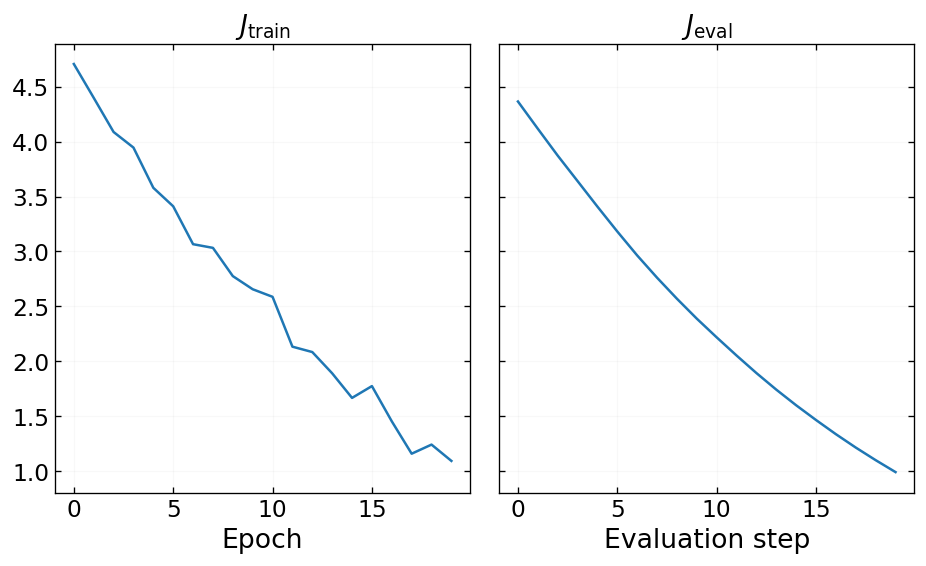

In [12]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)

ax[0].plot(res["J_train_hist"])
ax[0].set_title(r"$J_{\mathrm{train}}$")
ax[0].set_xlabel("Epoch")

ax[1].plot(res["J_eval_hist"])
ax[1].set_title(r"$J_{\mathrm{eval}}$")
ax[1].set_xlabel("Evaluation step")

plt.tight_layout()
plt.show()

In [14]:
next_price_fn = make_price_function(price_history, future_price, params)

S0_demo = S0_single.repeat(20, 1)

t_hist, S_hist, endog_hist, u_hist, A_hist, B_hist, c_hist, J_episode = rollout_trajectory(
    policy=policy,
    S0=S0_demo,
    T=24.0,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    seed=1,
    device=DEVICE,
)

print(f"Demo rollout J: {J_episode:.4f}")

Demo rollout J: 1.0610


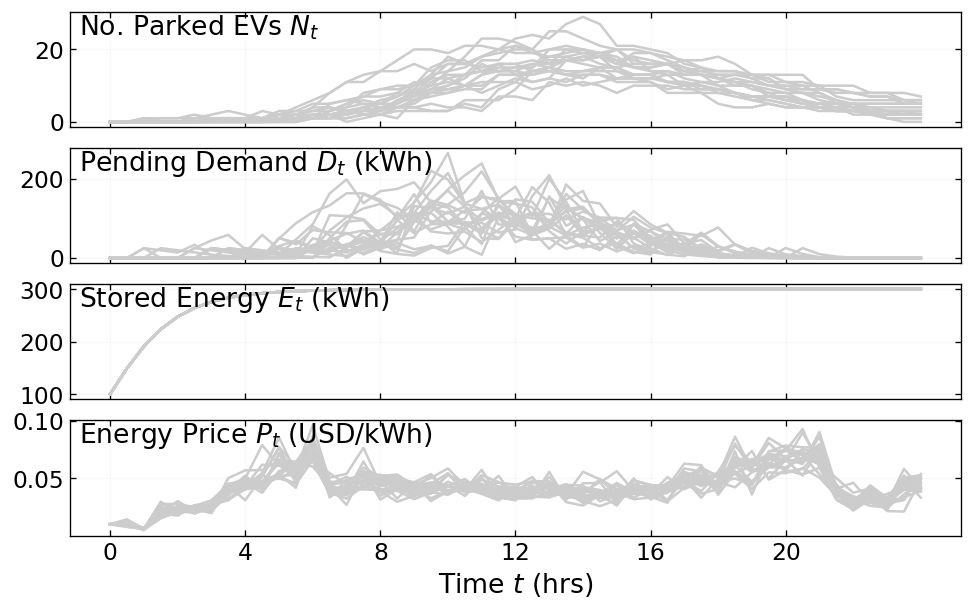

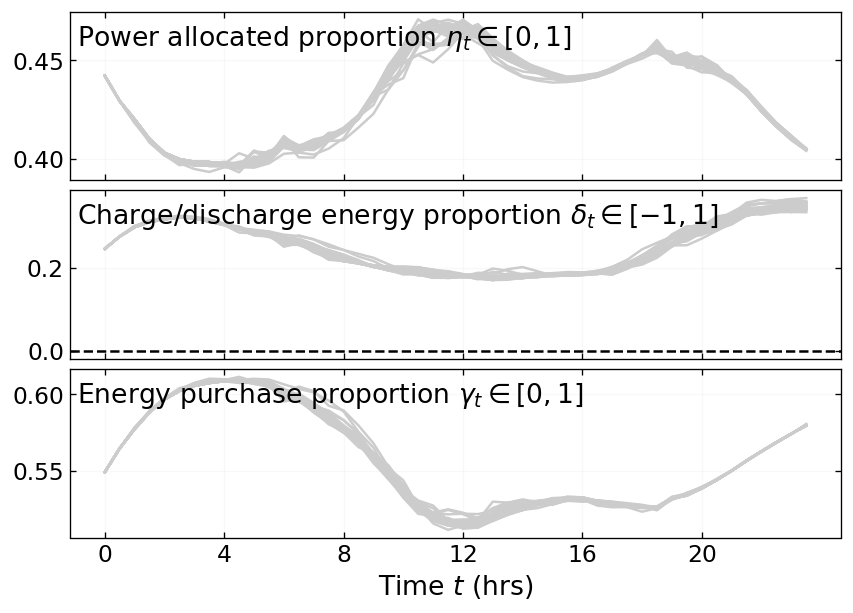

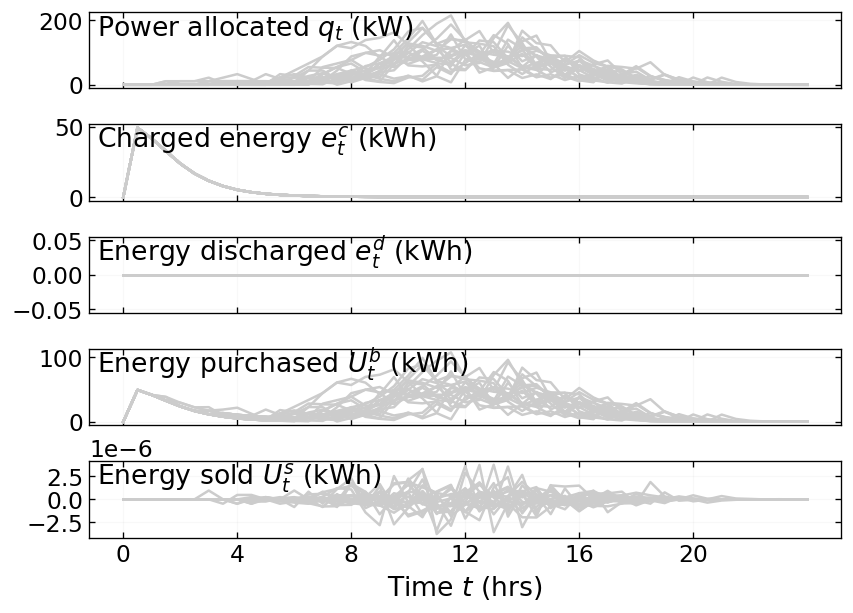

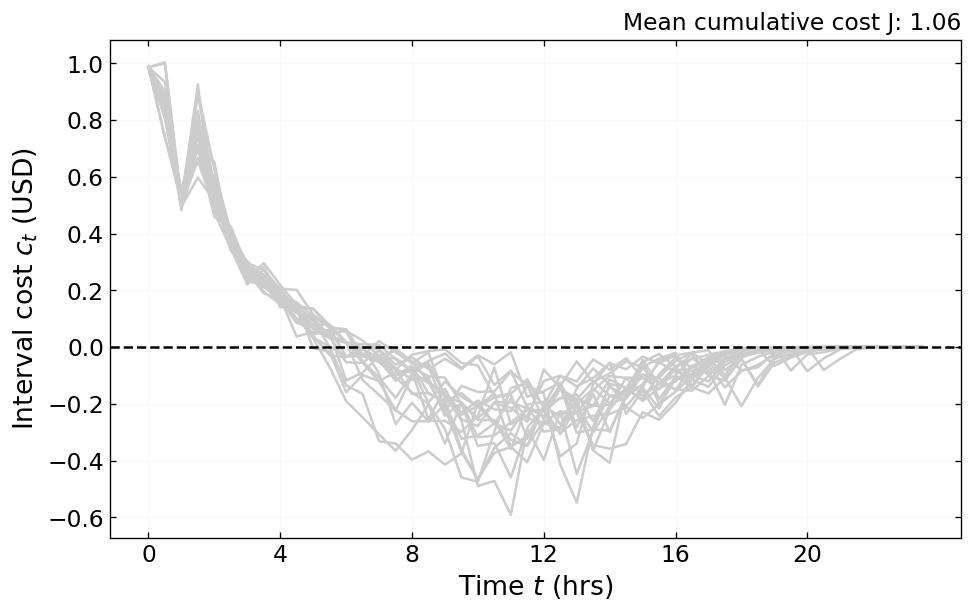

In [15]:
plot_state_trajectories(t_hist, S_hist)
plot_control_trajectories(t_hist, u_hist)
plot_endogenous_trajectories(t_hist, endog_hist)
plot_cost_trajectories(t_hist, c_hist, J_episode)